In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter, ExponentialFitter
from lifelines.utils import k_fold_cross_validation
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv('telco.csv')
df.drop(columns=['ID'], inplace=True)

In [11]:
binary_cols = ['retire', 'voice', 'internet', 'forward', 'churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [12]:
df['is_female'] = df['gender'].map({'Female': 1, 'Male': 0})
df['is_married'] = df['marital'].map({'Married': 1, 'Unmarried': 0})

In [13]:
categorical = ['region', 'ed', 'custcat']
df = pd.get_dummies(df, columns=categorical, drop_first=True)

In [14]:
df.drop(columns=['gender', 'marital'], inplace=True)
df.head()

,tenure,age,address,income,retire,voice,internet,forward,churn,is_female,is_married,region_Zone 2,region_Zone 3,ed_Did not complete high school,ed_High school degree,ed_Post-undergraduate degree,ed_Some college,custcat_E-service,custcat_Plus service,custcat_Total service
0,13,44,9,64,0,0,0,1,1,0,1,True,False,False,False,False,False,False,False,False
1,11,33,7,136,0,1,0,1,1,0,1,False,True,False,False,True,False,False,False,True
2,68,52,24,116,0,0,0,0,0,1,1,False,True,True,False,False,False,False,True,False
3,33,33,12,33,0,0,0,0,1,1,0,True,False,False,True,False,False,False,False,False
4,23,30,9,30,0,0,0,1,0,0,1,True,False,True,False,False,False,False,True,False


In [15]:
duration_col = 'tenure'
event_col = 'churn'
predictors = [col for col in df.columns if col not in [duration_col, event_col]]

In [16]:
weibull = WeibullAFTFitter().fit(df[[duration_col, event_col] + predictors], duration_col=duration_col, event_col=event_col)
lognormal = LogNormalAFTFitter().fit(df[[duration_col, event_col] + predictors], duration_col=duration_col, event_col=event_col)
loglogistic = LogLogisticAFTFitter().fit(df[[duration_col, event_col] + predictors], duration_col=duration_col, event_col=event_col)
exp = ExponentialFitter().fit(df[duration_col], event_observed=df[event_col])

In [17]:
print("Model AIC and Log-Likelihood:")
print(f"Weibull AIC:     {weibull.AIC_:.2f}, Log-Likelihood: {weibull.log_likelihood_:.2f}")
print(f"LogNormal AIC:   {lognormal.AIC_:.2f}, Log-Likelihood: {lognormal.log_likelihood_:.2f}")
print(f"LogLogistic AIC: {loglogistic.AIC_:.2f}, Log-Likelihood: {loglogistic.log_likelihood_:.2f}")
print(f"Exponential AIC: {exp.AIC_:.2f}, Log-Likelihood: {exp.log_likelihood_:.2f}")

Model AIC and Log-Likelihood:
Weibull AIC:     2964.34, Log-Likelihood: -1462.17
LogNormal AIC:   2954.02, Log-Likelihood: -1457.01
LogLogistic AIC: 2956.21, Log-Likelihood: -1458.10
Exponential AIC: 3215.96, Log-Likelihood: -1606.98


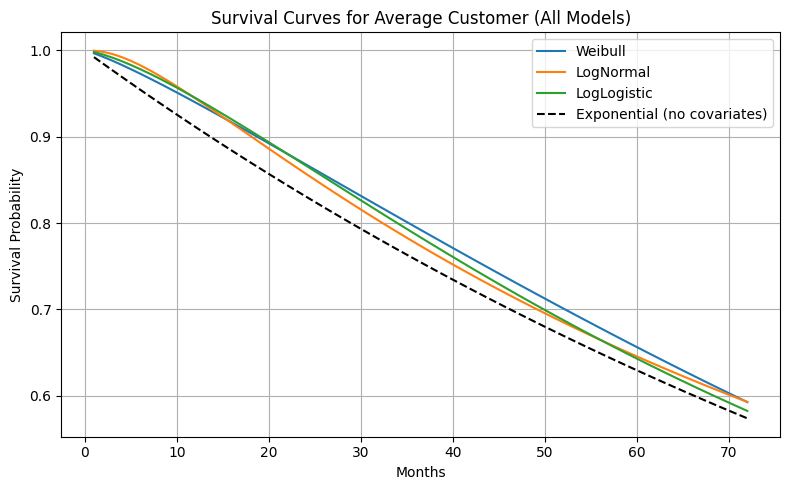

In [18]:
times = np.linspace(1, 72, 72)

X_avg = df[predictors].mean().to_frame().T

plt.figure(figsize=(8, 5))

plt.plot(times, weibull.predict_survival_function(X_avg, times=times).values.flatten(), label='Weibull')
plt.plot(times, lognormal.predict_survival_function(X_avg, times=times).values.flatten(), label='LogNormal')
plt.plot(times, loglogistic.predict_survival_function(X_avg, times=times).values.flatten(), label='LogLogistic')

plt.plot(times, exp.survival_function_at_times(times).values.flatten(), label='Exponential (no covariates)', linestyle='--', color='black')

plt.title("Survival Curves for Average Customer (All Models)")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
duration_col = 'tenure'
event_col = 'churn'

predictors = [col for col in df.columns if col not in [duration_col, event_col]]

significant_vars = lognormal.summary[lognormal.summary['p'] < 0.05].index.get_level_values(1)
significant_vars = [var for var in significant_vars if var != 'Intercept']

In [20]:
df_final = df[['tenure', 'churn'] + significant_vars].copy()

final_model = LogNormalAFTFitter().fit(df_final, duration_col='tenure', event_col='churn')

final_model.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1462.10
         time fit was run = 2025-05-01 18:20:25 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                              
mu_    address                0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                    0.04      1.04      0.01            0.02            0.05                1.02                1.05
       custcat_E-service      1.03      2.79      0.17            0.69            1.36                2.00                3.89
       custcat_Plus service   0.82      2.28      0.17            0.49            1.15                1.63                3.17
       custcat_Total service  1.01      2.75      0.21            0.60            1.42                1.83                4.15
       internet              -0.84      0.43      0.14           -1.11           -0.57                0.33                0.57
       is_married             0.45      1.56      0.11            0.22            0.67                1.25                1.96
       voice                 -0.46      0.63      0.17           -0.79           -0.14                0.45                0.87
       Intercept              2.09      8.07      0.24            1.62            2.55                5.06               12.84
sigma_ Intercept              0.28      1.33      0.05            0.19            0.37                1.21                1.45

                              cmp to     z      p  -log2(p)
param  covariate                                           
mu_    address                  0.00  4.84 <0.005     19.56
       age                      0.00  5.75 <0.005     26.78
       custcat_E-service        0.00  6.07 <0.005     29.53
       custcat_Plus service     0.00  4.85 <0.005     19.66
       custcat_Total service    0.00  4.83 <0.005     19.52
       internet                 0.00 -6.08 <0.005     29.63
       is_married               0.00  3.91 <0.005     13.39
       voice                    0.00 -2.78   0.01      7.52
       Intercept                0.00  8.79 <0.005     59.27
sigma_ Intercept                0.00  6.15 <0.005     30.27
---
Concordance = 0.78
AIC = 2944.20
log-likelihood ratio test = 280.83 on 8 df
-log2(p) of ll-ratio test = 183.73

In [21]:
X_final = df_final.drop(columns=['tenure', 'churn'])
surv_prob_1m = final_model.predict_survival_function(X_final, times=[1])
df['retention_1m'] = surv_prob_1m.iloc[0].values

m = 50  
i = 0.01 
AC = 100 
r = df['retention_1m']

df['CLV'] = (m * r) / (1 + i - r) - AC

df[['retention_1m', 'CLV']].head()

,retention_1m,CLV
0,0.999688,4747.426681
1,0.999736,4769.972497
2,0.999999,4899.479051
3,0.997985,4053.248213
4,0.999870,4835.302062


In [22]:
def income_group(val):
    if val < 30:
        return 'Low'
    elif val < 85:
        return 'Mid'
    else:
        return 'High'

df['income_group'] = df['income'].apply(income_group)

In [23]:
def plot_clv_density_by_segment(segment_col, labels_map=None):
    plt.figure(figsize=(8, 5))
    found_labels = []
    for val in sorted(df[segment_col].dropna().unique()):
        label = labels_map[val] if labels_map and val in labels_map else str(val)
        clvs = df[df[segment_col] == val]['CLV']
        if len(clvs) < 2:
            continue
        kde = gaussian_kde(clvs)
        x_vals = np.linspace(clvs.min(), clvs.max(), 300)
        plt.plot(x_vals, kde(x_vals), label=label)
        found_labels.append(label)
    plt.title(f"CLV Density by {segment_col}")
    plt.xlabel("Customer Lifetime Value")
    plt.ylabel("Density")
    if found_labels:
        plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

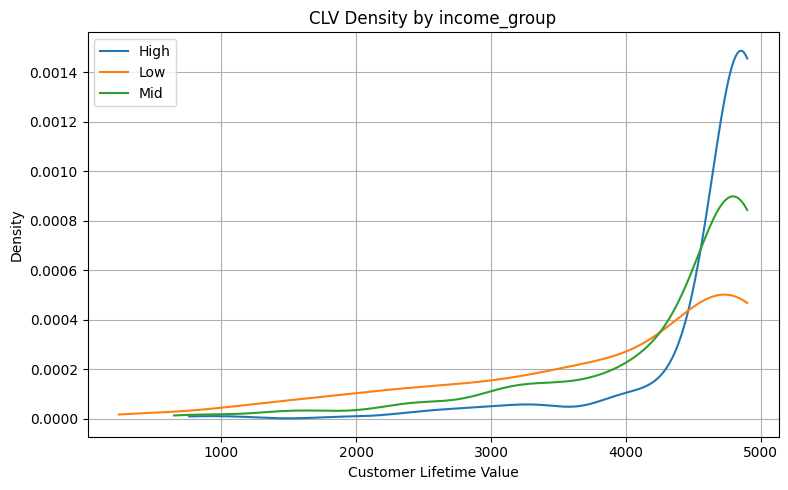

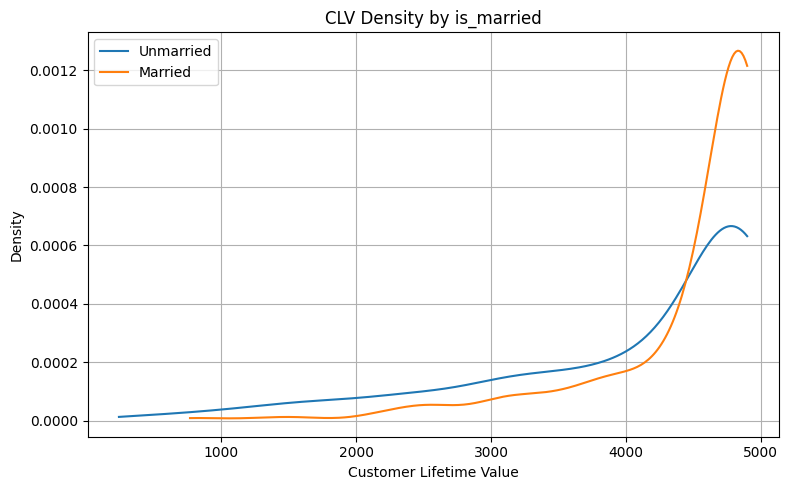

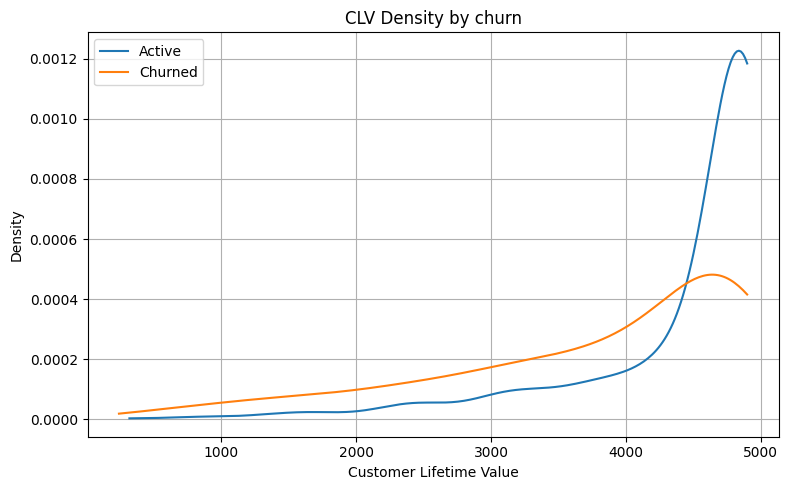

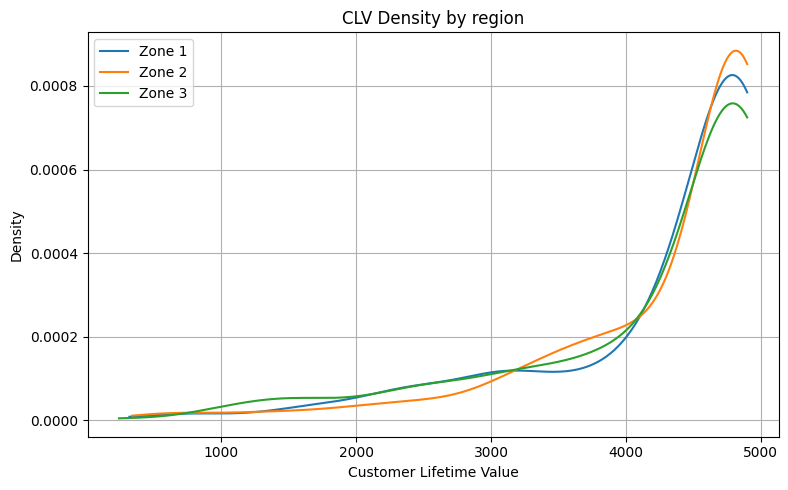

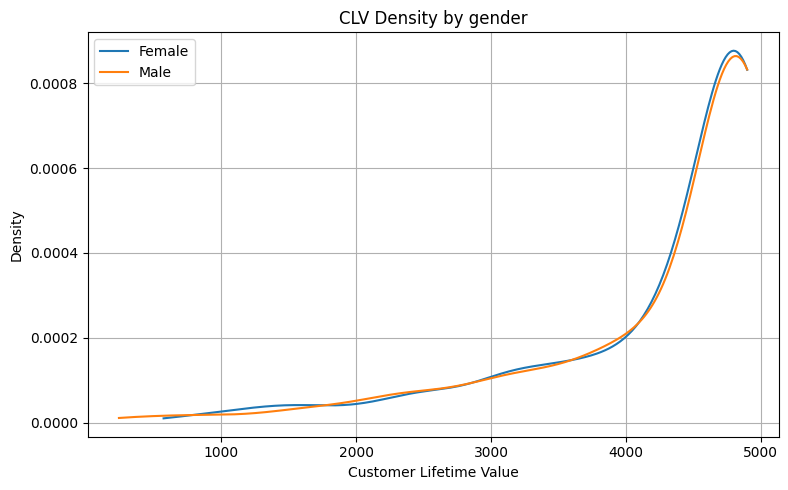

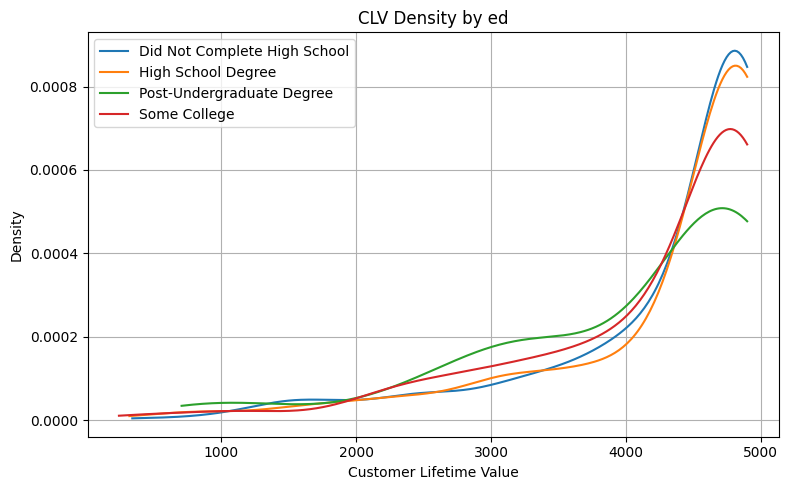

In [24]:
plot_clv_density_by_segment('income_group')

plot_clv_density_by_segment('is_married', labels_map={0: 'Unmarried', 1: 'Married'})

plot_clv_density_by_segment('churn', labels_map={0: 'Active', 1: 'Churned'})

if {'region_Zone 2', 'region_Zone 3'}.issubset(df.columns):
    df['region'] = np.select(
        [df['region_Zone 2'] == 1, df['region_Zone 3'] == 1],
        ['Zone 2', 'Zone 3'],
        default='Zone 1'
    )
plot_clv_density_by_segment('region')

if 'is_female' in df.columns:
    df['gender'] = df['is_female'].map({1: 'Female', 0: 'Male'})
    plot_clv_density_by_segment('gender')

ed_cols = [col for col in df.columns if col.startswith('ed_')]
if ed_cols:
    df['ed'] = df[ed_cols].idxmax(axis=1).str.replace('ed_', '').str.replace('_', ' ').str.title()
    plot_clv_density_by_segment('ed')

### Report Summary

The LogNormal AFT model, selected based on the lowest AIC (2944.20) and strong concordance (0.78), revealed several key factors influencing customer churn. Positive coefficients for variables like age, address stability, marital status, and subscription to Plus, Total, or E-service plans indicate a longer expected customer lifetime. Specifically, customers with E-service plans are nearly 2.8 times more likely to stay longer compared to basic plan users. In contrast, the use of internet and voice services was associated with significantly shorter tenure, suggesting that these customers may have higher churn risk—possibly due to increased engagement or sensitivity to service quality. All predictors were statistically significant (p < 0.05), and the model's log-likelihood ratio test further confirmed strong explanatory power.

Using survival probabilities at 1-month and estimated Customer Lifetime Value (CLV), the most valuable segments were identified as older, married customers on premium service plans, particularly those not subscribed to standalone internet or voice. "Valuable" customers are defined here as those with high predicted retention and positive long-term profitability after acquisition costs. From the CLV distribution, segments such as E-service and Plus service users, married individuals, and Zone 2 residents stood out. Assuming the dataset represents the population, and identifying ~25–30% of users with retention probabilities below 0.95 as “at risk,” an annual retention budget of $15,000 (e.g., $50 × 300 customers) is reasonable to preserve high-CLV customers. To reduce churn further, I recommend targeted interventions such as bundling plans, loyalty rewards, and early detection of at-risk profiles based on the predictors.